## 04. モデリング
> パイプライン位置: 01_data_collection → 02_eda → 03_sql → `04_modeling`

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
import shap
import sys
import os

sys.path.append(os.path.abspath('..'))

from src.db.connection import engine

plt.rcParams['font.family'] = 'YuMincho'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_sql("SELECT * FROM master_table", engine)

print(df.shape)
print(df.head())

(117, 13)
  year_month  egg_price  feed_ppi  electricity_ppi  egg_ppi  egg_cpi  \
0 2016-04-01       5259     94.82            98.81    89.81   86.773   
1 2016-05-01       5216     94.82            98.81    85.53   84.645   
2 2016-06-01       5260     94.82            98.81    87.35   84.451   
3 2016-07-01       5272     94.82            98.81    95.35   84.665   
4 2016-08-01       5332     94.82           100.00    97.00   85.258   

   feed_lag1  feed_lag2  feed_lag3  elec_lag1  elec_lag2  elec_lag3  regime  
0      94.82      95.69      95.69      98.81      98.81      98.81       0  
1      94.82      94.82      95.69      98.81      98.81      98.81       0  
2      94.82      94.82      94.82      98.81      98.81      98.81       0  
3      94.82      94.82      94.82      98.81      98.81      98.81       0  
4      94.82      94.82      94.82      98.81      98.81      98.81       0  


### ダミー変数の作成とデータ分割

時系列データの特性上、ランダム分割ではなく**時間順分割**を使用した。
- train: 2024年以前   
- test: 2024年以降

**AI ダミー変数の適用期間**
| 区分 | 期間 |
|---|---|
| 第1次 AI 波 | 2016年11月〜2017年9月 |
| 第2次 AI 波 | 2020年11月〜2021年10月 |

終了基準: 各波の最後の急騰落後、価格が安定的な推移に転換した時点にした。


In [2]:
df['ai_dummy'] = 0
df.loc[
    (df['year_month'] >= '2016-11-01') &
    (df['year_month'] <= '2017-09-01'), 'ai_dummy'] = 1   
df.loc[
    (df['year_month'] >= '2020-11-01') &
    (df['year_month'] <= '2021-10-01'), 'ai_dummy'] = 1   
print(df['ai_dummy'].value_counts())

train = df[df['year_month'] < '2024-01-01'].reset_index(drop=True)
test  = df[df['year_month'] >= '2024-01-01'].reset_index(drop=True)

print("train:", train.shape)  
print("test :", test.shape)  

features = [
    'feed_ppi', 'electricity_ppi',
    'feed_lag1', 'feed_lag2', 'feed_lag3',
    'elec_lag1', 'elec_lag2', 'elec_lag3'
]

features_with_dummy = [
    'feed_ppi', 'electricity_ppi',
    'feed_lag1', 'feed_lag2', 'feed_lag3',
    'elec_lag1', 'elec_lag2', 'elec_lag3',
    'ai_dummy',
    'regime'      
]

X_train = train[features]
y_train = train['egg_price']
X_test  = test[features]
y_test  = test['egg_price']

X_train_d = train[features_with_dummy]
X_test_d  = test[features_with_dummy]

df.to_csv("../data/processed/master_table_with_dummy.csv", index=False)
print("ai_dummy 含む CSV 保存完了")

ai_dummy
0    94
1    23
Name: count, dtype: int64
train: (93, 14)
test : (24, 14)
ai_dummy 含む CSV 保存完了


> ai_dummy=1 の期間は、第1次11ヶ月 + 第2次12ヶ月、合計23ヶ月。

In [3]:
df[df['ai_dummy'] == 0].groupby('regime')['egg_price'].mean()

regime
0    5177.181818
1    6596.800000
Name: egg_price, dtype: float64

> 平常時のregime=0 平均5,177ウォンに対し、regime=1は6,597ウォンで   
> 2021年以降に価格水準が構造的に切り上がったことが数値に表れた。

---

### モデル1. OLS — ベースライン
機械学習モデルと比較するための基準点として使った。   
係数とp値で統計的有意性を数値で示せるため、後続モデルの解釈を補完する役割も担う。

In [4]:
X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)

model_ols = sm.OLS(y_train, X_train_sm).fit()
print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:              egg_price   R-squared:                       0.188
Model:                            OLS   Adj. R-squared:                  0.111
Method:                 Least Squares   F-statistic:                     2.438
Date:                Sun, 24 May 2026   Prob (F-statistic):             0.0202
Time:                        22:11:03   Log-Likelihood:                -764.11
No. Observations:                  93   AIC:                             1546.
Df Residuals:                      84   BIC:                             1569.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            3516.9772    964.041     

#### 多重共線性の確認 — VIF
OLS係数を解釈する前に、変数間の多重共線性を定量的に確認した。

In [5]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = pd.DataFrame({
    '변수': X_train.columns,
    'VIF': [variance_inflation_factor(X_train.values, i) 
            for i in range(X_train.shape[1])]
}).sort_values('VIF', ascending=False)

print(vif_df)

                변수           VIF
2        feed_lag1  31710.970556
3        feed_lag2  30495.163148
4        feed_lag3  13268.105306
0         feed_ppi  12248.774813
6        elec_lag2   4424.730071
5        elec_lag1   4296.111570
1  electricity_ppi   3317.703942
7        elec_lag3   2996.341504


> 全変数のVIFが基準値10を大幅に超えた。   
> 同一変数のラグ列を同時投入した構造上避けられないため、係数の解釈はRF変数重要度とSHAPに委ねる。

#### 標準化係数の比較
単位の異なる変数の影響力を同一基準で比較するため、標準化を適用する。


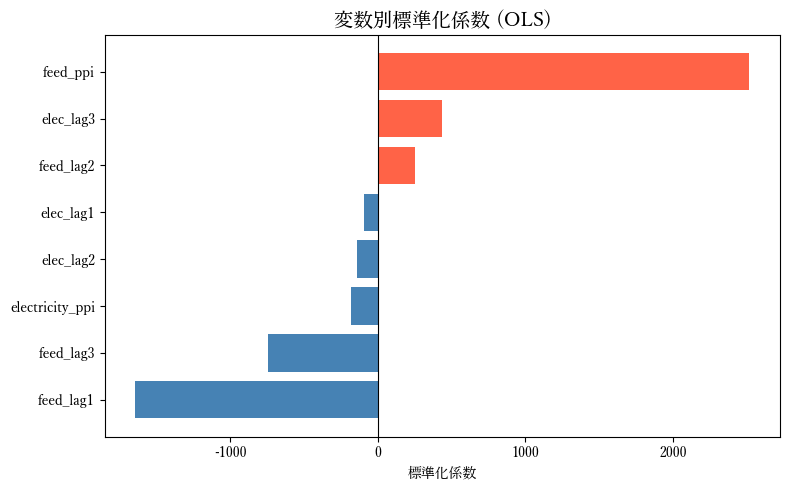

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

X_scaled_const = sm.add_constant(X_scaled)
model_std = sm.OLS(y_train, X_scaled_const).fit()

coef_df = pd.DataFrame({
    '変数': X_train.columns,
    '標準化係数': model_std.params[1:]
}).sort_values('標準化係数', ascending=True)

plt.close('all') 

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['tomato' if c > 0 else 'steelblue' for c in coef_df['標準化係数']]
ax.barh(coef_df['変数'], coef_df['標準化係数'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('変数別標準化係数 (OLS)', fontsize=14)
ax.set_xlabel('標準化係数')
plt.tight_layout()
plt.savefig('../output/figures/std_coefficients.png', dpi=150)
plt.show()

> feed_ppiが正方向で最大の係数を示した。feed_lag1の負値は多重共線性による歪みとみて因果解釈からは除いた。

**H1 検証 — 飼料費の即時転嫁**

> 02_eda のラグ別相関では lag0=0.462 が最高値でラグ増加とともに単調減少しており、   
> RF変数重要度でもfeed_ppiが単独1位だった。   
> 月次転嫁の強度は限定的だが、飼料費が現時点で最も価格に連動する変数であることは確認できたため   
> `H1を条件付きで採択`した。

---


### モデル2. Random Forest
OLSは多重共線性の下では係数が信頼できず、線形関係しか捉えられない。   
RFは多重共線性の影響を受けにくく、変数重要度で各特徴量の貢献度を直接読み取れる点を評価して採用した。 

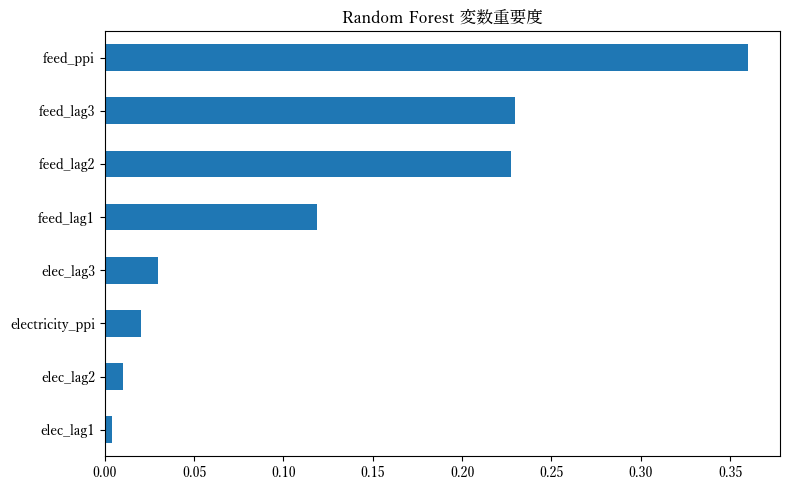

In [7]:
plt.close('all') 

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=features)
importances.sort_values().plot(kind='barh', figsize=(8, 5))


plt.title('Random Forest 変数重要度')
plt.tight_layout()
plt.savefig('../output/figures/rf_importance.png', dpi=150)
plt.show()

>feed_ppi 単独で約35%、feed 系列合計で約94%と、飼料費が圧倒的に高い重要度を示した。   
>電力系列合計は約6%で、飼料費と比べ約15倍以上の差があった。   
> -> `H2採択`  


----


### モデル3. XGBoost
RFと同じ特徴量でブースティング系の結果を比較したかった。   
SHAPと組み合わせると変数の寄与方向まで確認できる点も、採用の理由になった。

In [8]:
xgb = XGBRegressor(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

#### SHAP分析

変数重要度が影響力の大きさのみを示すのとは異なり   
SHAP は各変数が予測値を上げるか下げるか、方向性まで確認できる。

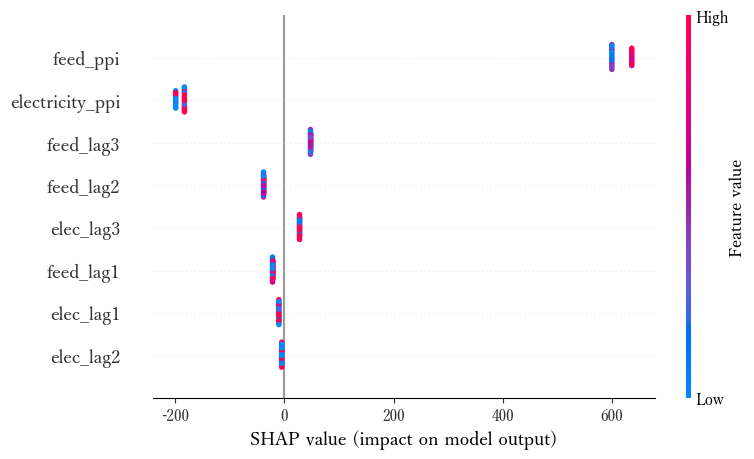

In [9]:
plt.close('all') 

explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test,
                  feature_names=features,
                  show=False)
                  
plt.tight_layout()
plt.savefig('../output/figures/shap_summary.png', dpi=150)
plt.show()

> feed_ppiが高いほど予測価格を押し上げる方向に寄与しており   
> SHAP寄与値は最大 +600ウォン水準だった。   
>RFの変数重要度と方向が一致し飼料費の影響を別手法で裏付けた。

---

### モデル4. RF + AI ダミー 
前の3モデルはコスト変数のみで学習した。   
H3検証のため`AIダミー`と`regime`を加え、外部ショック期間がコスト-価格の連動構造をどう変えるかを定量的に確かめた。

In [10]:
rf_d = RandomForestRegressor(n_estimators=100, random_state=42)
rf_d.fit(X_train_d, y_train)

pred_rf_d = rf_d.predict(X_test_d)
rmse_d = np.sqrt(mean_squared_error(y_test, pred_rf_d))
mae_d  = mean_absolute_error(y_test, pred_rf_d)

print(f"RF (コスト+AI+regime) -> RMSE: {rmse_d:.0f}ウォン, MAE: {mae_d:.0f}ウォン")

RF (コスト+AI+regime) -> RMSE: 272ウォン, MAE: 228ウォン


#### H3 定量検証 —  期間別の連動構造比較

In [11]:
df_ai     = df[df['ai_dummy'] == 1]
df_normal = df[df['ai_dummy'] == 0]

for label, subset in [('AIショック期', df_ai), ('平常時', df_normal)]:
    X = sm.add_constant(subset['feed_ppi'])
    model = sm.OLS(subset['egg_price'], X).fit()
    corr  = subset['egg_price'].corr(subset['feed_ppi'])
    print(f"{label} (n= {len(subset)}): feed_ppi相関 = {corr:.3f}, R²= {model.rsquared:.3f}")

AIショック期 (n= 23): feed_ppi相関 = -0.141, R²= 0.020
平常時 (n= 94): feed_ppi相関 = 0.893, R²= 0.798


| 期間 | feed_ppi相関 | R² | 解釈 |
|------|-------------|-----|------|
| 平常時 (n=94) | **0.893** | 0.798 | コストが価格変動の約80%を説明 |
| AIショック期 (n=23) | **-0.141** | 0.020 | コスト-価格連動が完全に断絶 |

<br>

> 平常時はコストが価格変動の約80%を説明していたが、   
> AIショック期には相関が逆転し連動がほぼ消えた。   
> コスト以外の要因が価格を動かしていた構造が数値に出た。-> `H3採択`

#### RF + AI ダミー 変数重要度とSHAP

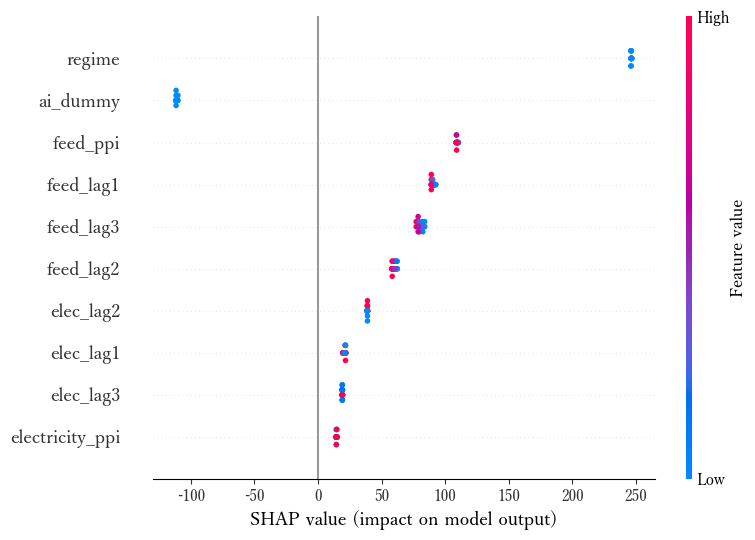

In [12]:
plt.close('all') 

explainer_d = shap.TreeExplainer(rf_d)
shap_values_d = explainer_d.shap_values(X_test_d)

shap.summary_plot(shap_values_d, X_test_d,
                  feature_names=features_with_dummy,
                  show=False)
plt.tight_layout()
plt.savefig('../output/figures/shap_summary_rf_dummy.png', dpi=150)
plt.show()

>regimeが正方向で最大の寄与を示し、ai_dummyも価格を押し上げる方向に働いていた。   
>コスト変数の中では`feed_ppi`が引き続き最上位だが`ダミー変数`2つが上位を占める構造になった。

In [13]:
imp_d = pd.Series(rf_d.feature_importances_, index=features_with_dummy)
dummy_sum = imp_d['ai_dummy'] + imp_d['regime']
cost_sum  = imp_d[features].sum()
feed_sum = imp_d[['feed_ppi','feed_lag1','feed_lag2','feed_lag3']].sum()
elec_sum = imp_d[['electricity_ppi','elec_lag1','elec_lag2','elec_lag3']].sum()

print(f"ai_dummy:  {imp_d['ai_dummy']:.1%}")
print(f"regime:    {imp_d['regime']:.1%}")
print(f"ダミー合計: {dummy_sum:.1%}")
print(f"コスト合計: {cost_sum:.1%}")
print(f"feed 系列合計: {feed_sum:.1%}")
print(f"elec 系列合計: {elec_sum:.1%}")

ai_dummy:  37.1%
regime:    13.9%
ダミー合計: 51.0%
コスト合計: 49.0%
feed 系列合計: 37.7%
elec 系列合計: 11.3%


> ダミー合計がコスト合計を上回り   
> AIショックの有無とレジーム区分が飼料費や電力費より予測への寄与が大きかった。   
>-> `H3の追加根拠`

---

#### モデル性能比較と最終モデル選択

In [14]:
results = {}

pred_ols = model_ols.predict(X_test_sm)
results['OLS'] = {
    'RMSE': np.sqrt(mean_squared_error(y_test, pred_ols)),
    'MAE' : mean_absolute_error(y_test, pred_ols)
}

pred_rf = rf.predict(X_test)
results['RF'] = {
    'RMSE': np.sqrt(mean_squared_error(y_test, pred_rf)),
    'MAE' : mean_absolute_error(y_test, pred_rf)
}

pred_xgb = xgb.predict(X_test)
results['XGB'] = {
    'RMSE': np.sqrt(mean_squared_error(y_test, pred_xgb)),
    'MAE' : mean_absolute_error(y_test, pred_xgb)
}

results['RF+dummy'] = {
    'RMSE': np.sqrt(mean_squared_error(y_test, pred_rf_d)),
    'MAE' : mean_absolute_error(y_test, pred_rf_d)
}

for name, result in results.items():
    print(f"{name} -> RMSE: {result['RMSE']:.0f}ウォン, MAE: {result['MAE']:.0f}ウォン")

OLS -> RMSE: 286ウォン, MAE: 226ウォン
RF -> RMSE: 274ウォン, MAE: 229ウォン
XGB -> RMSE: 344ウォン, MAE: 281ウォン
RF+dummy -> RMSE: 272ウォン, MAE: 228ウォン


| モデル | RMSE | MAE |
|------|------|-----|
| OLS | 286ウォン | 226ウォン |
| Random Forest | 274ウォン | 229ウォン |
| XGBoost | 344ウォン | 281ウォン |
| RF + AI ダミー | 272ウォン | 228ウォン |

<br>

> XGBoostは RFよりRMSEが70ウォン高く    
>このデータではブースティングの優位性は出なかった。       
> RF+AIダミーは数値上の改善幅は小さいが、AIショック期の相関逆転という構造的な根拠があるため最終モデルとした。


#### 実測値 vs 予測値の可視化

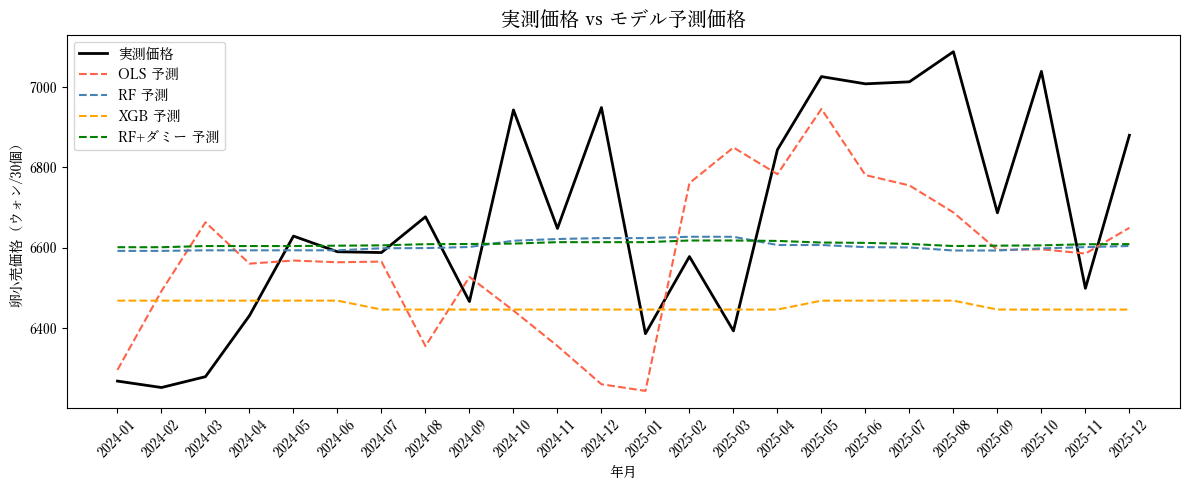

In [15]:
plt.close('all')

fig, ax = plt.subplots(figsize=(12, 5))

x = range(len(y_test))

ax.plot(x, y_test.values, label='実測価格', color='black', linewidth=2)
ax.plot(x, pred_ols,      label='OLS 予測', color='tomato',    linestyle='--')
ax.plot(x, pred_rf,       label='RF 予測',  color='steelblue', linestyle='--')
ax.plot(x, pred_xgb, label='XGB 予測', color='orange', linestyle='--')
ax.plot(x, pred_rf_d, label='RF+ダミー 予測', color='green', linestyle='--')

ax.set_title('実測価格 vs モデル予測価格', fontsize=14)

ax.set_xlabel('年月')
ax.set_xticks(x)
ax.set_xticklabels(test['year_month'].dt.strftime('%Y-%m'), rotation=45)

ax.set_ylabel('卵小売価格（ウォン/30個）')
ax.legend()

plt.tight_layout()
plt.savefig('../output/figures/actual_vs_predicted.png', dpi=150)
plt.show()

In [16]:
print(f"RF 予測範囲: {pred_rf.min():.0f}ウォン 〜 {pred_rf.max():.0f}ウォン")
print(f"RF+ダミー 予測範囲: {pred_rf_d.min():.0f}ウォン 〜 {pred_rf_d.max():.0f}ウォン")
print(f"実測価格範囲: {y_test.min():.0f}ウォン 〜 {y_test.max():.0f}ウォン")
print(f"実測 7,000ウォン以上の期間: {(y_test >= 7000).sum()}ヶ月")

test['predicted_rf'] = pred_rf
test['predicted_rf_d'] = pred_rf_d
test[['year_month', 'egg_price', 'predicted_rf', 'predicted_rf_d']].to_csv(
    '../data/processed/predictions.csv', index=False
)
print("予測値 CSV 保存完了")

RF 予測範囲: 6592ウォン 〜 6627ウォン
RF+ダミー 予測範囲: 6601ウォン 〜 6618ウォン
実測価格範囲: 6252ウォン 〜 7088ウォン
実測 7,000ウォン以上の期間: 5ヶ月
予測値 CSV 保存完了


In [17]:
model_performance = pd.DataFrame({
    'model': list(results.keys()),
    'RMSE': [round(v['RMSE']) for v in results.values()],
    'MAE':  [round(v['MAE'])  for v in results.values()]
})
model_performance.to_csv('../data/processed/model_performance.csv', index=False)

print("モデル性能 CSV 保存完了")

モデル性能 CSV 保存完了


> 全モデルで実測価格が7,000ウォンを超えた5ヶ月間を捉えられなかった。   
> 需給・季節性・政策変数が手元にないことが原因で、この点は今後の課題として残る。



---

### 結論

飼料費が卵価格の変動を最も強く規定する変数であることが、RF重要度のfeed系列94%とSHAPの両面から確認できた。   
ただしこの連動は外部ショック時には機能しなくなる。平常時はR²=0.798でコストが価格変動の約80%を説明できるが   
AIショック期にはR²=0.020まで下がり、相関係数も0.893から-0.141へ逆転した。   
最終モデルとして選んだRF+AIダミーのRMSEが272ウォン数値上の改善幅こそ小さいが   
この構造的断絶がダミー変数の必要性を裏付けている。   

※需給・季節性データが未取得であること、2017年の殺虫剤卵パニックのような需要側ショックへの対応が含まれていないことは、本分析の限界として残る。  


---

### 📌 ビジネス活用

####  シナリオ1 — 仕入れタイミングの判断（バイヤー・調達担当）   
平常時の価格下限の目安はregime=1平均の約6,597ウォンで　   
小売価格がこの水準に近づいた場合は底値での仕入れ機会として判断できる。   

> 判断基準: `小売価格 ≤ 6,597ウォン AND ai_dummy = 0`
---

#### シナリオ2 — コスト異常シグナルの検知（運営・企画）

予測値と実測価格の乖離が`±2×RMSEの約550ウォン`を超えた場合    
需給異常のシグナルとして早期検知に使える。      

> アラート条件: `|実測価格 − 予測価格| > 550ウォン AND ai_dummy = 0`

---

#### シナリオ3 — AI波の早期検知チェックリスト（リスク管理）
  
飼料費が安定しているにもかかわらず小売価格が急騰した場合    
コスト予測モデルへの依存を下げ、需給量や殺処分規模データのモニタリングに切り替える判断基準になる。

> 切替条件: `飼料費安定 AND 小売価格急騰 → ai_dummy = 1 期間への移行有無を確認`